In [1]:
!pip install langchain langchain_community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 39.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 9.1 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [2]:
!pip install langchain-groq
from langchain_groq import ChatGroq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 7.8 MB/s eta 0:00:00


In [ ]:
GROQ_API_KEY = "YOUR_GROQ_API_KEY"  # Replace with your actual API key

llm = ChatGroq( 
    model="openai/gpt-oss-120b",
    api_key=GROQ_API_KEY,
)

In [ ]:
from langgraph.graph import START,END,StateGraph
from typing import TypedDict

In [5]:
class State(TypedDict):
  question:str
  intent:str
  answer:str

In [ ]:
def classify(state):
  intent_question = llm.invoke(f"""
  Analyze the following user question and classify its intent.

  Question:{state['''question''']}

  Classification rules:
  1. If the question is about a complaint, problem, issue, failed transaction, or dissatisfaction,
    return: complaint

  2. If the question is about creating, opening, registering, or setting up a new account,
    return: account

  3. If the question is about checking account balance, available balance, current balance,
    mini statement, or balance-related information,
    return: balance

  Important:
  - Return ONLY one of these three words: complaint, account, balance
  - Do not provide any explanation.
  - Do not use punctuation.
  - Use lowercase only.
""")
  return{"intent":intent_question}

In [7]:
def check_balance(state):
  balance="10000"
  return{"answer":f"Your account balance is {balance}"}

In [8]:
def account(state):
  account_message="Visit bank tomorrow to create account. thank you for connecting with us"
  return {"answer":account_message}

In [9]:
def complaint(state):
  message_complaint="your complaint has been registered"
  return {"answer":message_complaint}

In [10]:
def route(state):
  intent_content = state["intent"].content.strip().lower()

  if intent_content == "complaint":
    return "complaint"
  elif intent_content == "account":
    return "account"
  elif intent_content == "balance":
    return "check_balance"

In [11]:
builder=StateGraph(State)

In [12]:
builder.add_node("classify",classify)
builder.add_node("check_balance",check_balance)
builder.add_node("account",account)
builder.add_node("complaint",complaint)

In [ ]:
builder.add_edge(START,"classify")
builder.add_conditional_edges(
    'classify',
    route,{
        'complaint':"complaint",
        'account':"account",
        'check_balance':"check_balance",
    }
)
builder.add_edge("complaint",END)
builder.add_edge("account",END)
builder.add_edge("check_balance",END)

In [14]:
graph=builder.compile()

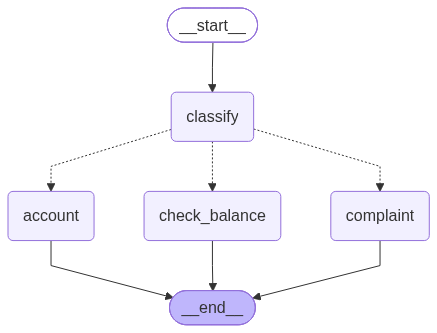

In [15]:
from IPython.display import Image, display

# Render and display the graph
display(Image(graph.get_graph().draw_mermaid_png()))

In [16]:
graph.invoke({
    "question":"I WANT TO OPEN ZERO KHATA ACCOUNT",
    "intent":"",
    "answer":""
})

{'question': 'I WANT TO OPEN ZERO KHATA ACCOUNT',
 'intent': AIMessage(content='account', additional_kwargs={'reasoning_content': 'The user question: "I WANT TO OPEN ZERO KHATA ACCOUNT". That\'s about opening a new account. So classification: account. Return "account".'}, response_metadata={'token_usage': {'completion_tokens': 41, 'prompt_tokens': 225, 'total_tokens': 266, 'completion_time': 0.08681184, 'completion_tokens_details': {'reasoning_tokens': 31}, 'prompt_time': 0.010065263, 'prompt_tokens_details': None, 'queue_time': 0.171714594, 'total_time': 0.096877103}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_5781dfb07c', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a03e1f-a532-7c10-90bf-8db28570addc-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 225, 'output_tokens': 41, 'total_tokens': 266, 'output_token_details': {'reasoning': 31}}),
 'answer': 'Visit bank tomorrow to